# Sorghum growth

In [6]:
from __future__ import annotations

import os
import sys
import time
from datetime import date
from multiprocessing import Pool

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

sys.path.append("../data") 
from archi_dict import archi_sorghum_PMA as archi
from openalea.widgets.plantgl import *  # noqa: F403

from plot_outputs import *

from openalea.archicrop.archicrop import ArchiCrop
from openalea.archicrop.stand import agronomic_plot
from openalea.archicrop.stics_io import stics_output
from openalea.archicrop.display import build_scene, display_scene  # noqa: F401
from openalea.plantgl.all import Color3, Material, Scene, Viewer  # noqa: F401

%gui qt

In [2]:
tec_file='../data/02NT18SorgV2D1_tec.xml'
plant_file='../data/plant/sorgho_imp_M_v10_plt.xml'
stics_output_file='../data/mod_s02NT18SorgV2D1.sti'
stics_output_file_pot='../data/mod_s02NT18SorgV2D1_no_stress.sti'

density, daily_dynamics, lifespan, lifespan_early, thermal_time, leaf_area_plant, sen_leaf_area_plant, height_canopy, end_juv, end_veg, index_end_veg = stics_output(tec_file, plant_file, stics_output_file)
density_pot, daily_dynamics_pot, lifespan_pot, lifespan_early_pot, thermal_time_pot, leaf_area_plant_pot, sen_leaf_area_plant_pot, height_canopy_pot, end_juv_pot, end_veg_pot, index_end_veg_pot = stics_output(tec_file, plant_file, stics_output_file_pot)

In [8]:
pot_factor = 1.5
archi['nb_phy'] = 12
archi['phyllochron'] = compute_phi(archi['nb_phy'], end_veg)
archi['leaf_area'] = max(height_canopy_pot)*pot_factor
archi['height'] = max(leaf_area_plant_pot)*pot_factor

start = time.time()
plant = ArchiCrop(daily_dynamics=daily_dynamics, **archi)
plant.generate_potential_plant()
mtgs = plant.grow_plant(rate=False)
end = time.time()
print(f"Time for 1 simulation of {len(mtgs)} days: {end-start}")

Time for 1 simulation of 119 days: 1.989607572555542


In [9]:
# Retrieve STICS growth and senescence dynamics
dates = [value["Date"] for value in daily_dynamics.values()]
thermal_time = [value["Thermal time"] for value in daily_dynamics.values()]
leaf_area_plant = [value["Plant leaf area"] for value in daily_dynamics.values()]
sen_leaf_area_plant = [value["Plant senescent leaf area"] for value in daily_dynamics.values()]
height_canopy = [value["Plant height"] for value in daily_dynamics.values()]
par_incident = [value["Incident PAR"] for value in daily_dynamics.values()]
par_stics = [value["Absorbed PAR"] for value in daily_dynamics.values()]

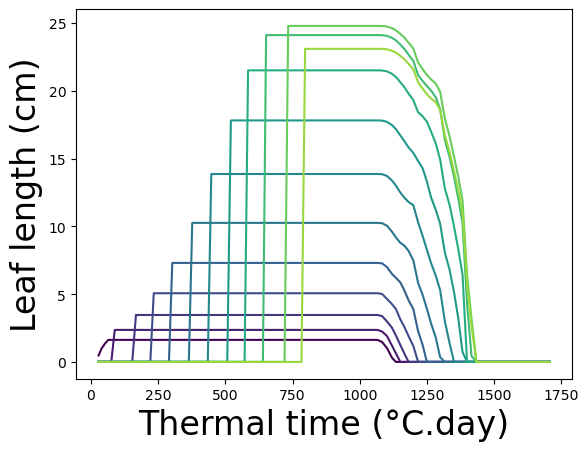

In [10]:
import os
from datetime import date

### Plot leaf lengths
norm = plt.Normalize(0, len(mtgs[1].properties()["leaf_lengths"].values())+1)
cmap = plt.get_cmap('viridis') 

for l in range(len(mtgs[100].properties()["leaf_lengths"].values())): 
    color = cmap(norm(l))
    plt.plot(thermal_time[1:], 
             [list(mtgs[t].properties()["leaf_lengths"].values())[l][-1] - list(mtgs[t].properties()["senescent_lengths"].values())[l][-1] for t in range(1,len(thermal_time))], 
             color=color)

plt.xlabel("Thermal time (°C.day)", fontsize=24)
plt.ylabel("Leaf length (cm)", fontsize=24)

# Save figure
today_str = date.today().strftime("%Y-%m-%d")
os.makedirs(f"../figures/", exist_ok=True)  
plt.savefig(f"../figures/plot_leaf_lengths.png", dpi=1000)

plt.show()

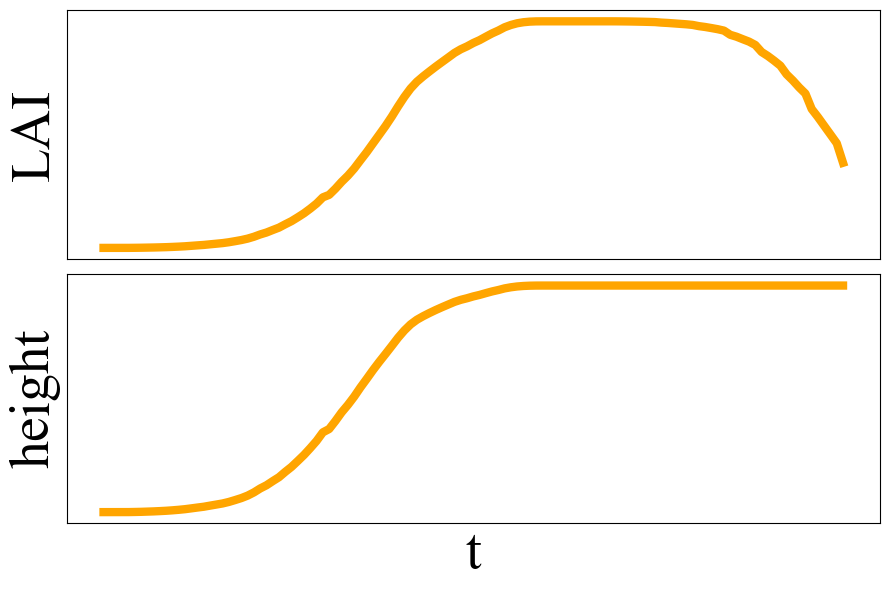

In [14]:
# conversion factor
cf_cm = 100

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)  # 1 row, 2 columns

axes[0].plot(range(len(dates)), [(la-sen)*density/cf_cm**2 for la, sen in zip(leaf_area_plant, sen_leaf_area_plant)], color='orange', linewidth=6)
axes[0].set_ylabel("LAI", fontsize=40, fontname="Times New Roman")
axes[0].set_yticks([])
axes[0].set_xticks([])

axes[1].plot(range(len(dates)), [h/cf_cm for h in height_canopy], color='orange', linewidth=6)
axes[1].set_xlabel("t", fontsize=40, fontname="Times New Roman")
axes[1].set_ylabel("height", fontsize=40, fontname="Times New Roman")
axes[1].set_yticks([])
axes[1].set_xticks([])

# Adjust layout
plt.tight_layout()

# Save figure
today_str = date.today().strftime("%Y-%m-%d")
os.makedirs(f"../figures/", exist_ok=True)  
plt.savefig(f"../figures/plot_constrainted_vs_realized.png", dpi=1000)

# Show the plot
plt.show()

In [ ]:
### Plot the 3D scene
# times = [t for i,t in enumerate(thermal_time) if i%10==0]
# mean_time = sum(times) / len(times)
# positions = [ (1*(t-mean_time), 0, 0) for t in times]
# nice_green = Color3((40, 80, 0))
# scene, _ = build_scene(
#     [g for i,g in enumerate(mtgs[id]) if i%10==0], 
#     position=positions, 
#     senescence=True, 
#     leaf_material = Material(nice_green), 
#     stem_material=Material(nice_green))
# display_scene(scene)

In [ ]:
len(mtgs)

36

In [ ]:
nice_green = Color3((40, 80, 0))
nplants, positions, domain, domain_area, unit = agronomic_plot(length=1, width=1, density=density, inter_row=0.4, noise=0.15)
# scene, nump = build_scene(mtgs[40][-32], positions, senescence=True, leaf_material=Material(nice_green), stem_material=Material(nice_green))
# Viewer.camera.lookAt((0,0,500), (0,0,0))
# display_scene(scene)

# for id,mtg in mtgs.items():
#     scene, nump = build_scene(mtg[-32], positions, senescence=True, leaf_material=Material(nice_green), stem_material=Material(nice_green))
#     Viewer.display(scene)
#     Viewer.grids.setXYPlane(False)
#     Viewer.grids.setYZPlane(False)
#     Viewer.grids.setXZPlane(False)
#     Viewer.camera.lookAt((0,0,500), (0,0,0))
#     Viewer.frameGL.saveImage(f"../figures/sorghum_{params_sets[id]['insertion_angle']}_{params_sets[id]['curvature']}_{params_sets[id]['phyllotactic_angle']}.png")

In [ ]:
from openalea.archicrop.light_it import illuminate
%gui qt

par_incident = [value["Incident PAR"] for value in daily_dynamics.values()]

id = 10
mtgs_plant = mtgs[id]
t = -32
mtg = mtgs_plant[t]
par = par_incident[t]
lights = [(1,(0,0,-1))]
scene, labels = build_scene(mtg, positions, senescence=True, leaf_material=Material(nice_green), stem_material=Material(nice_green))
cs, raw, agg = illuminate(scene=scene, light=lights, labels=labels, domain=domain, direct=False) # --> cf PARaggregators in caribu scene node
scene, values = cs.plot(raw, display=False)
v99 = np.percentile(values, 99)
nvalues=np.array(values)
nvalues[nvalues>v99]=v99
values = nvalues.tolist()
PlantGL(scene, group_by_color=False, property=values)
# scene_tmp = cs.plot(raw, display=False)[0]
# scene_tmp.save(f'../figures/illuminated_scene_{i}.png') # not as images !!!

Plot(antialias=3, axes=['x', 'y', 'z'], axes_helper=1.0, axes_helper_colors=[16711680, 65280, 255], background…